In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
# ===== Загрузка =====
df = pd.read_csv("social.csv")

#### ===== Подготовка признаков =====

In [3]:
# Целевая переменная
target = "Healthcare_1"


In [4]:
# Признаки, которые будем использовать
features = ["Social_1", "Social_2", "Social_3", 
            "Helthcare_2", "Price", "DistrictId"]

In [5]:
# Разделяем данные на обучающие и те, где нужно предсказать
train_df = df[df[target].notna()].copy()
test_df  = df[df[target].isna()].copy()

X_train = train_df[features]
y_train = train_df[target]

X_test  = test_df[features]

 ===== Модель RandomForest =====

In [6]:
model = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [7]:
model.fit(X_train, y_train)

RandomForestRegressor(min_samples_leaf=2, n_estimators=400, n_jobs=-1,
                      random_state=42)

In [8]:

# ===== Прогнозируем пропуски =====
preds = model.predict(X_test)


In [9]:
# Записываем финальный столбец
df["Healthcare_1_filled"] = df["Healthcare_1"]
df.loc[df[target].isna(), "Healthcare_1_filled"] = preds

print("Готово! Пропуски в Healthcare_1 восстановлены в колонке Healthcare_1_filled.")

Готово! Пропуски в Healthcare_1 восстановлены в колонке Healthcare_1_filled.


In [10]:
# ===== Оценка качества на обучающей части =====
train_pred = model.predict(X_train)

print("R2:", r2_score(y_train, train_pred))
print("MAE:", mean_absolute_error(y_train, train_pred))

R2: 0.999045354406208
MAE: 3.3350377209162527


In [11]:
# ===== Важность признаков =====
importances = pd.Series(model.feature_importances_, index=features)
print("\nВажность признаков:")
print(importances.sort_values(ascending=False))


Важность признаков:
Social_3       0.309254
Social_2       0.236550
Social_1       0.182078
DistrictId     0.171667
Helthcare_2    0.099137
Price          0.001314
dtype: float64


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Social_1             10000 non-null  int64  
 1   Social_2             10000 non-null  int64  
 2   Social_3             10000 non-null  int64  
 3   Healthcare_1         5202 non-null   float64
 4   Helthcare_2          10000 non-null  int64  
 5   Price                10000 non-null  float64
 6   DistrictId           10000 non-null  int64  
 7   Healthcare_1_filled  10000 non-null  float64
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [17]:
df.head(10)

,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Price,DistrictId,Healthcare_1_filled
0,33,7976,5,NaN,0,184966.930730,35,874.008750
1,46,10309,1,240.0,1,300009.450063,41,240.000000
2,34,7759,0,229.0,1,220925.908524,53,229.000000
3,23,5735,3,1084.0,0,175616.227217,58,1084.000000
4,35,5776,1,2078.0,2,150226.531644,99,2078.000000
5,35,7715,4,990.0,0,215898.447742,59,990.000000
6,20,4386,14,NaN,1,296021.204377,154,803.197500
7,6,1437,3,NaN,0,221244.156664,74,821.705000
8,1,264,0,NaN,0,229102.795999,1,272.968368
9,6,1437,3,NaN,0,95380.220993,23,1469.985119


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

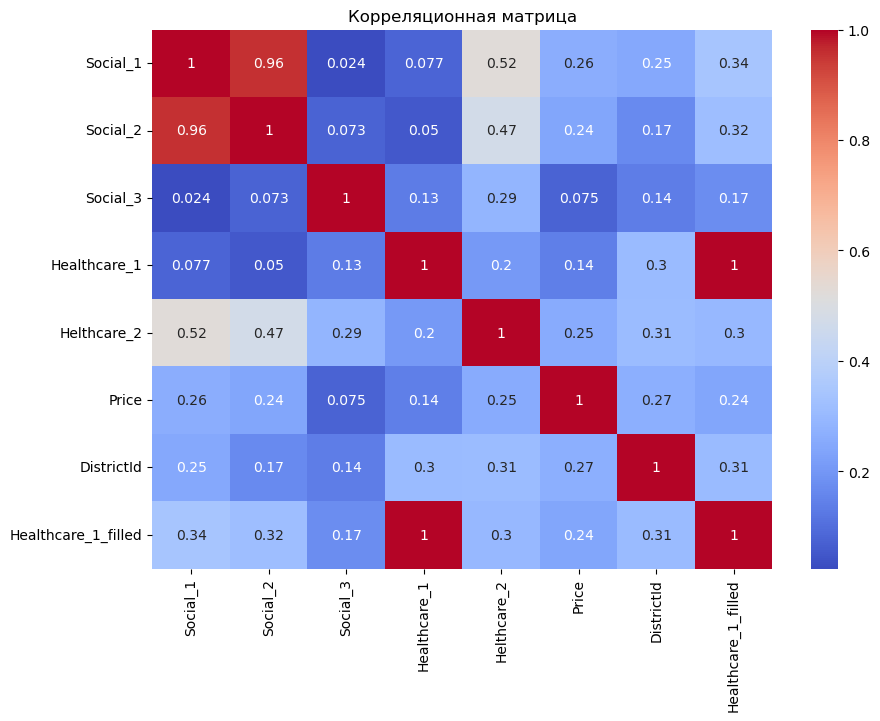

In [16]:
# --- Корреляции ---
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()